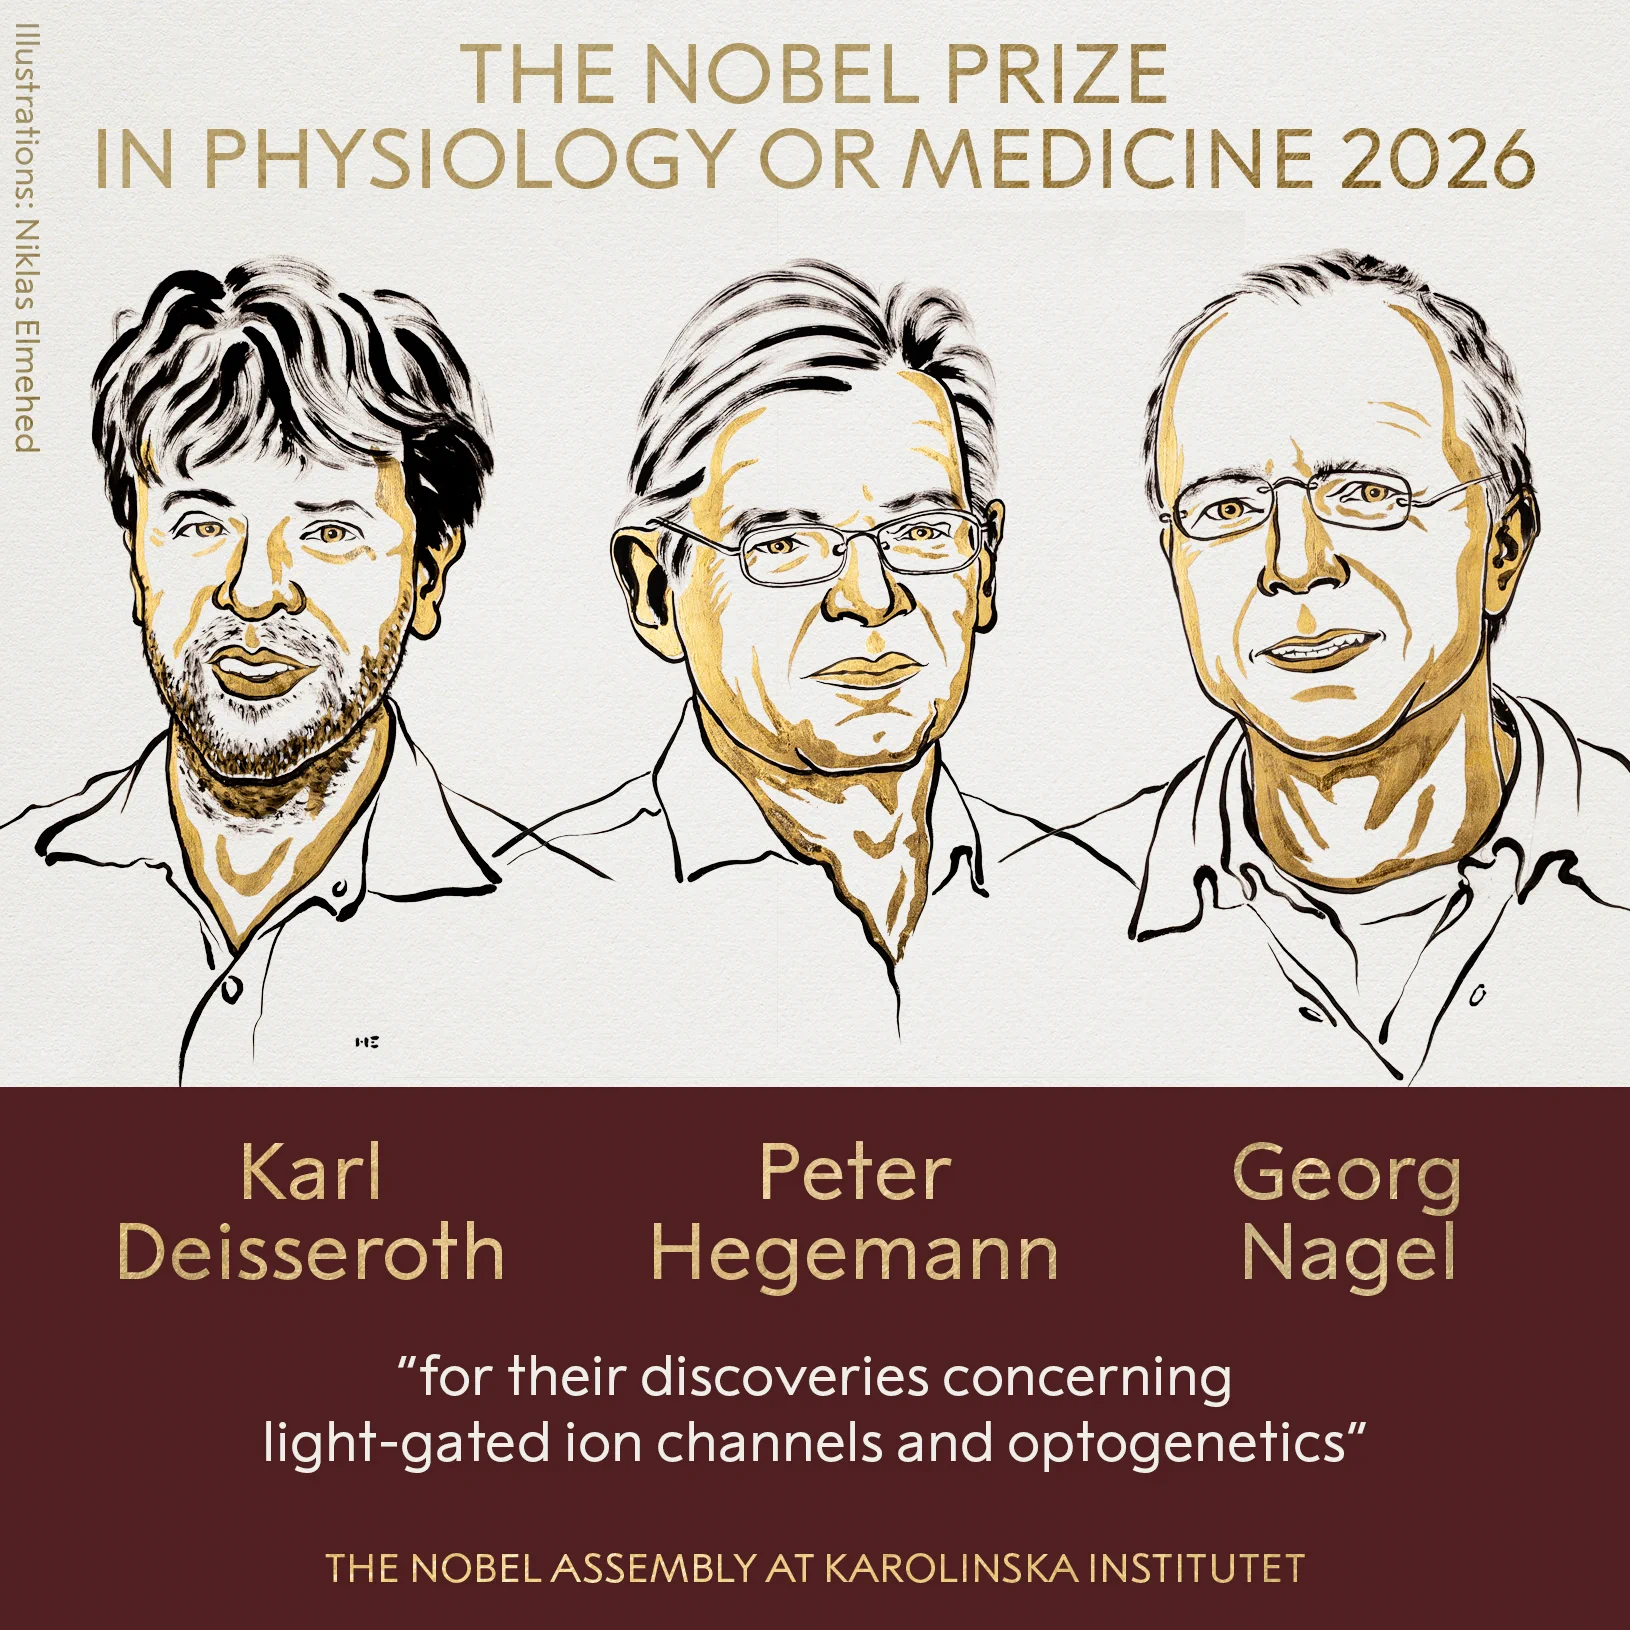

In [2]:
#Loading Necessary Packages
# This is used to access Python interactive environment. This way we can feed input and receive output as we code.
from IPython.core.interactiveshell import InteractiveShell
InteractiveShell.ast_node_interactivity = "all"

import pandas as pd #this package will be used for managing dataframes and excel sheets
import numpy as np  #this package will be used to perform math functions
import seaborn as sns # this package will be used to add aesthetics for data visualization 
import matplotlib.pyplot as plt
!pip install seaborn

# **Event Detection Analysis**

One of the more common types of analysis you will encounter in neuroscience research is **event detection analysis**. At its core, this approach is about identifying when something **meaningful** happens in your data.

Some examples may include:

- **EEG/EMG:** Detecting sleep spindles, REM twitches, or muscle bursts.

- **Fiber photometry:** Identifying dopamine transients when animals transition to wakefulness. 

- **Behavioral data:** Detecting lever presses or nose pokes in an operant task.

- **Electrophysiology:** Identifying spikes or bursts of neural activity.

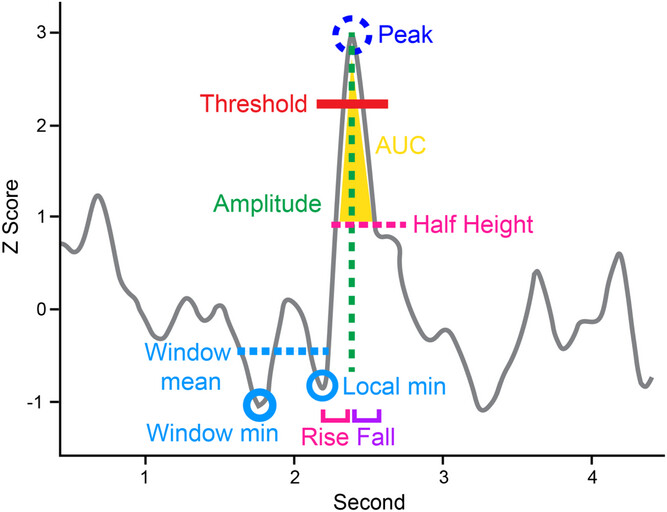

# Counting Peaks: Finding a library

Scipy: https://docs.scipy.org/doc/scipy/reference/generated/scipy.signal.find_peaks.html



# **What is find_peaks?**

find_peaks is a function from the SciPy library (scipy.signal) that helps us find the local peaks in a 1-D signal (like your EMG data).

A peak is simply a point that is higher than its neighbors (like the top of a mountain)

**From Skipy Library Example:**

- x → your list/array of fiber photometry values.
- peaks → a list of indices (positions) where peaks are found.
- _ → a dictionary with details about the peaks (heights, widths, etc.).

In [3]:
fp_results = pd.read_excel("photometry_results.xlsx", "Sheet1")
fp_results

,time_sec,dFF_final,sleep_state
0,600.000000,42.500081,NR
1,600.099976,42.670202,NR
2,600.200012,41.364608,NR
3,600.299988,37.573356,NR
4,600.400024,35.634919,NR
...,...,...,...
10646,1664.599976,-17.702618,R
10647,1664.699951,-18.136893,R
10648,1664.800049,-18.634621,R
10649,1664.900024,-17.438031,R


Text(0.5, 0, 'Time (seconds)')

Text(0, 0.5, 'dF/F')

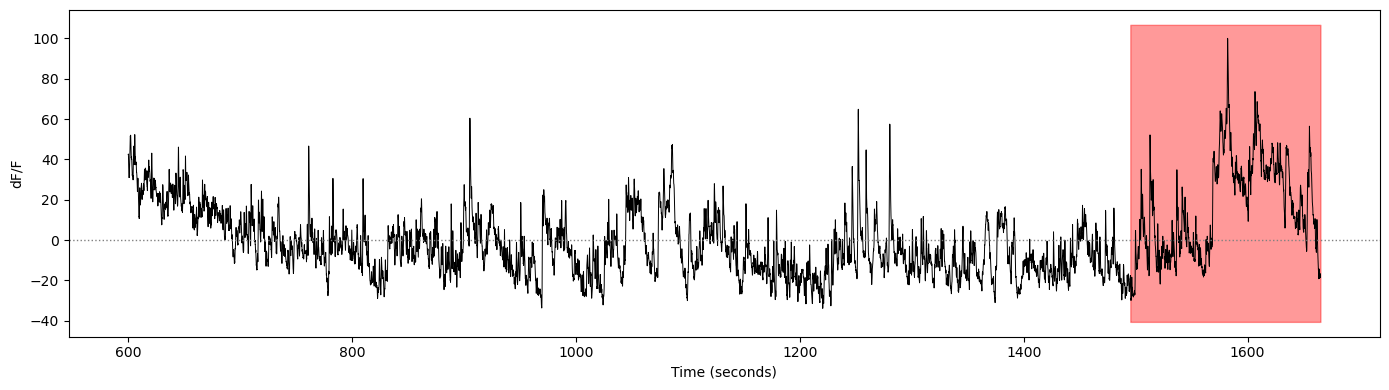

In [5]:
fig, ax = plt.subplots(figsize=(14, 4))

# Plot the signal
ax.plot(fp_results["time_sec"], fp_results["dFF_final"], color="black", linewidth=0.7)
ax.axhline(0, color="gray", linestyle=":", linewidth=1)

# Shade wherever sleep_state is "R"
ax.fill_between(
    fp_results["time_sec"],
    ax.get_ylim()[0], ax.get_ylim()[1],
    where=(fp_results["sleep_state"] == "R"),
    color="red", alpha=0.4
)

ax.set_xlabel("Time (seconds)")
ax.set_ylabel("dF/F")
plt.tight_layout()
plt.show()

In [46]:
from scipy.signal import find_peaks
import numpy as np

# Accessing rows that are labeled REMs (R)
rem_data = fp_results[fp_results["sleep_state"] == "R"]
rem_signal = rem_data["dFF_final"].to_numpy()

# Threshold: 2 standard deviations above the mean of the REMs signal
threshold = rem_signal.mean() + 2 * rem_signal.std()

# Detect peaks above that threshold
peaks, properties = find_peaks(rem_signal, height=threshold)

print("Threshold (mean + 2*std):", threshold)
print("Number of peaks above threshold:", len(peaks))

Threshold (mean + 2*std): 64.17870413637053
Number of peaks above threshold: 5


# **Comprehension Question**

Do you think it’s a problem that we are determining a separate threshold for each state? Could this affect our results if we want to compare the number of peaks across states?

ANSWER HERE

# **What we have learned so far?**

RECAP OF WHAT WE LEARNED DURING TUTORIAL 2-3

In [47]:
print(pd.ExcelFile("DATA_tutorial4.xlsx").sheet_names) #check your excel file sheets via sheet_names

['mouse1 ', 'mouse2']


In [48]:
data = pd.read_excel("DATA_tutorial4.xlsx") #will ONLY load FIRST sheet 
data

,Trial,DF/F (%),Muscle Activity (%),Duration (s),State
0,1,30.0,320,1000,W
1,2,32.0,248,570,W
2,3,-5.0,100,120,NR
3,4,0.0,100,90,NR
4,5,25.0,90,68,R
5,6,20.0,88,78,R
6,7,26.0,200,380,W
7,8,38.0,280,450,W
8,9,21.0,92,100,R
9,10,-2.4,100,136,NR


In [49]:
data_all_mice = pd.read_excel("DATA_tutorial4.xlsx", sheet_name= None) #loading all data
data_all_mice

{'mouse1 ':    Trial   DF/F (%)   Muscle Activity (%)   Duration  (s)  State 
 0       1       30.0                   320            1000      W
 1       2       32.0                   248             570      W
 2       3       -5.0                   100             120     NR
 3       4        0.0                   100              90     NR
 4       5       25.0                    90              68      R
 5       6       20.0                    88              78      R
 6       7       26.0                   200             380      W
 7       8       38.0                   280             450      W
 8       9       21.0                    92             100      R
 9      10       -2.4                   100             136     NR,
 'mouse2':    Trial   DF/F (%)   Muscle Activity (%)   Duration  (s)  State 
 0       1       34.0                   400             920      W
 1       2       29.0                   310             610      W
 2       3       -4.0                   

In [50]:
data_mouse2 = pd.read_excel("DATA_tutorial4.xlsx", "mouse2") #loading specific sheet
data_mouse2

,Trial,DF/F (%),Muscle Activity (%),Duration (s),State
0,1,34.0,400,920,W
1,2,29.0,310,610,W
2,3,-4.0,100,145,NR
3,4,1.0,100,82,NR
4,5,23.0,88,72,R
5,6,19.0,82,85,R
6,7,27.0,299,410,W
7,8,36.0,420,485,W
8,9,22.0,93,110,R
9,10,-1.8,100,128,NR


In [51]:
type(data_all_mice) #dictionary saves multiple sheets from your excel 

dict

Combining 2 Data Frames 

In [52]:
combined_data = [] #storing data for our new data frame

for mouse_id, data in data_all_mice.items(): #loop through each mouse and data attach for each mouse
    data["mouse_id"] = mouse_id #tags each row with a new label
    combined_data.append(data) #add  all of our data 

combined_data

combined_df = pd.concat(combined_data, ignore_index=True)
combined_df

[   Trial   DF/F (%)   Muscle Activity (%)   Duration  (s)  State  mouse_id
 0       1       30.0                   320            1000      W  mouse1 
 1       2       32.0                   248             570      W  mouse1 
 2       3       -5.0                   100             120     NR  mouse1 
 3       4        0.0                   100              90     NR  mouse1 
 4       5       25.0                    90              68      R  mouse1 
 5       6       20.0                    88              78      R  mouse1 
 6       7       26.0                   200             380      W  mouse1 
 7       8       38.0                   280             450      W  mouse1 
 8       9       21.0                    92             100      R  mouse1 
 9      10       -2.4                   100             136     NR  mouse1 ,
    Trial   DF/F (%)   Muscle Activity (%)   Duration  (s)  State  mouse_id
 0       1       34.0                   400             920      W   mouse2
 1       2 

,Trial,DF/F (%),Muscle Activity (%),Duration (s),State,mouse_id
0,1,30.0,320,1000,W,mouse1
1,2,32.0,248,570,W,mouse1
2,3,-5.0,100,120,NR,mouse1
3,4,0.0,100,90,NR,mouse1
4,5,25.0,90,68,R,mouse1
5,6,20.0,88,78,R,mouse1
6,7,26.0,200,380,W,mouse1
7,8,38.0,280,450,W,mouse1
8,9,21.0,92,100,R,mouse1
9,10,-2.4,100,136,NR,mouse1


In [53]:
combined_df.columns = ["trial #", "DFF %", "Mus Act %", "Dur s", "State", "mID"] #we can change our column names
combined_df

,trial #,DFF %,Mus Act %,Dur s,State,mID
0,1,30.0,320,1000,W,mouse1
1,2,32.0,248,570,W,mouse1
2,3,-5.0,100,120,NR,mouse1
3,4,0.0,100,90,NR,mouse1
4,5,25.0,90,68,R,mouse1
5,6,20.0,88,78,R,mouse1
6,7,26.0,200,380,W,mouse1
7,8,38.0,280,450,W,mouse1
8,9,21.0,92,100,R,mouse1
9,10,-2.4,100,136,NR,mouse1


# **We can summarizing and manipulating our data via built-in functions** 

Some useful examples include (but are not limited to):

- **query()**:filter your DataFrame by specific criteria (e.g., select only WT or KO mice).

- **groupby()**: group your data by experimental group (e.g., WT vs KO) to compare them easily.

- **aggregate()**: apply multiple math functions (like mean, min, max) at once to summarize columns.

In [54]:
summary_exp_df = (combined_df

                  # Group by State
                  .groupby(by=['State'])

                  # Summarize DF/F for each state
                  .agg({
                      'DFF %': ["mean", "min", "max", "std"]
                  })

                  # Reset index
                  .reset_index()

                  # Set State as a category
                  .astype({'State': 'category'})
)

summary_exp_df

State      DFF %                      
              mean   min   max       std
0    NR  -2.033333  -5.0   1.0  2.288813
1     R  21.666667  19.0  25.0  2.160247
2     W  31.500000  26.0  38.0  4.276180

## What are the advantages of keeping our data organized and normalized? 

- **Reproducibility**: Anyone can trace a result back to exactly what produced it. When information is scattered across spreadsheets, filenames, and lab notebooks, re-running an analysis months later becomes guesswork
- **Fewer errors**: Copy-pasting values between spreadsheets is one of the most common sources of mistakes in research.
- **Putting variables on a common scale**: The absolute amplitude you record depends heavily on things that have nothing to do with brain activity: how deep the screw sits (for EEG recordings), whether it's touching or pressing on the dura, skull thickness, the exact position relative to the target region (for optogenetics), the quality of the connection to the wire and headmount.Two animals with identical brain activity can produce raw signals that differ just because of surgery. With typical group sizes (around 6-8 mice), a couple of animals with unusually good or poor contact can drive the whole result. 
- **It's a prerequisite for most advanced analysis**: Organizing and normalizing our data isn't just good housekeeping. It's a prerequisite for most advanced analysis. Machine learning, clustering, and other computational methods assume the data is consistent and comparable. If it isn't, they'll still give us an answer, just not one we can trust.

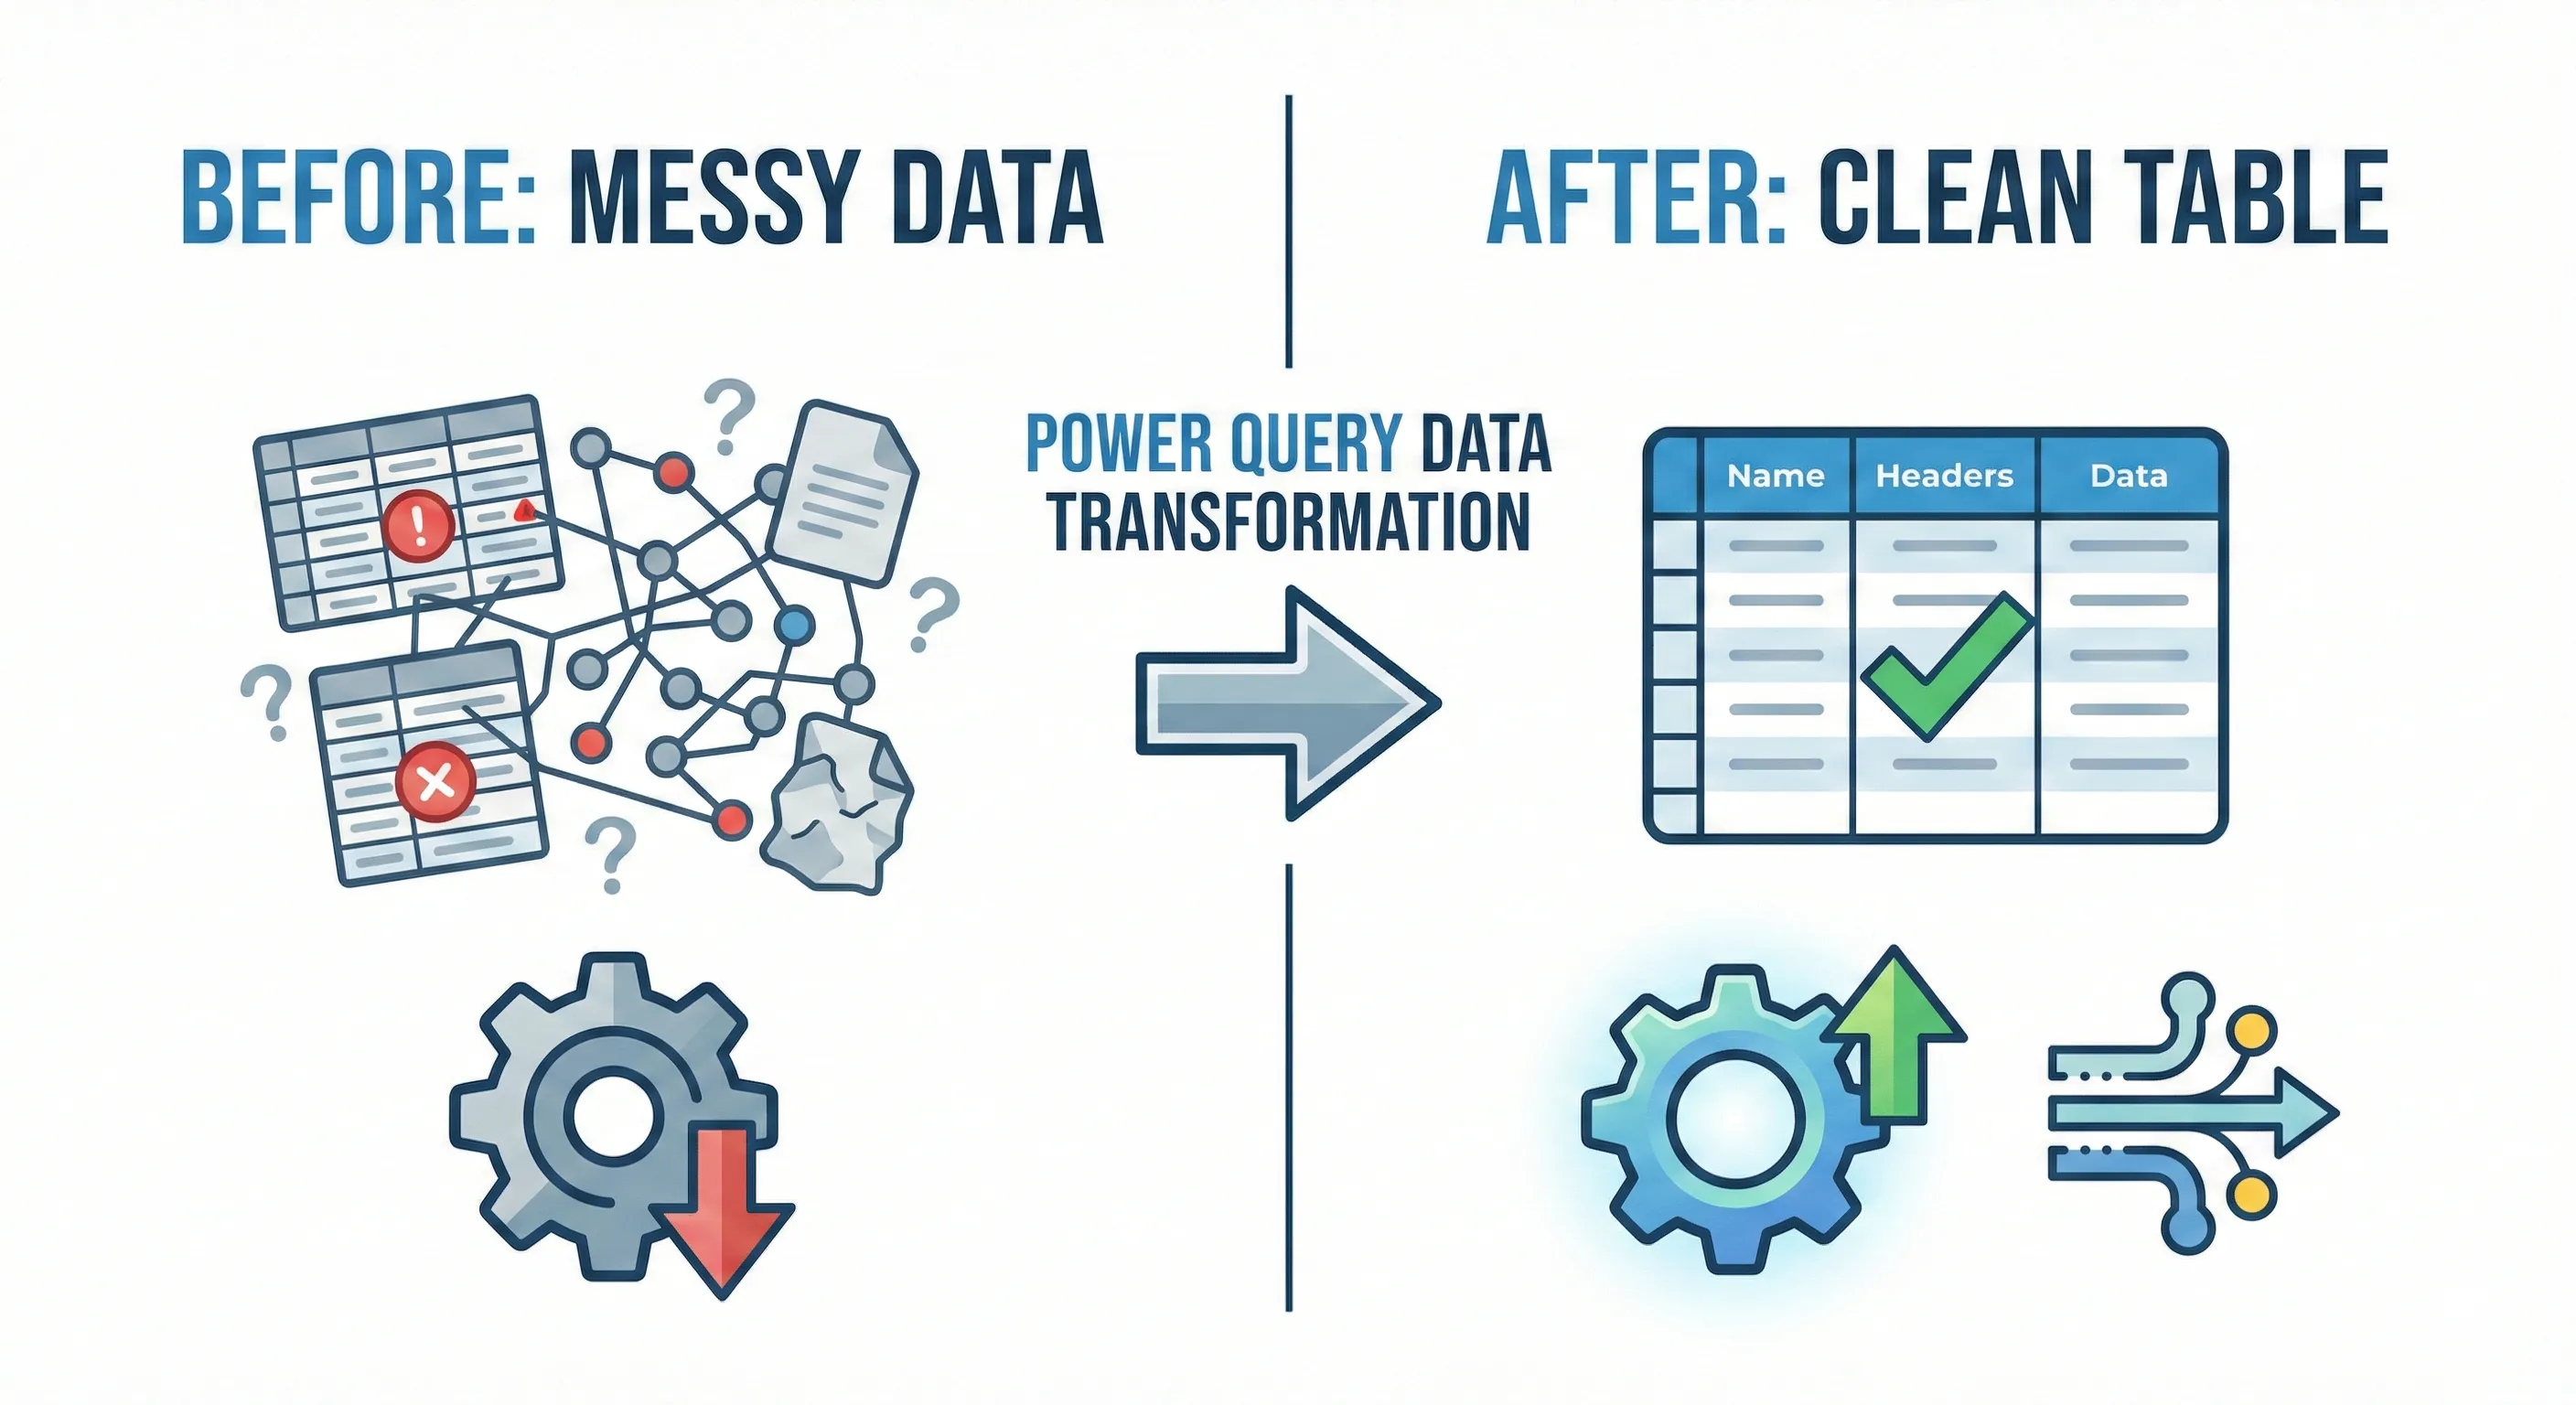

In [55]:
for state, data in combined_df.groupby('State'):
    
    matrix = data[
        ['DFF %', 'Mus Act %', 'Dur s']
    ].corr()
    
    print(state)
    print(matrix)
    

NR
             DFF %  Mus Act %    Dur s
DFF %      1.00000        NaN -0.78893
Mus Act %      NaN        NaN      NaN
Dur s     -0.78893        NaN  1.00000
R
              DFF %  Mus Act %     Dur s
DFF %      1.000000   0.511716 -0.359867
Mus Act %  0.511716   1.000000  0.460153
Dur s     -0.359867   0.460153  1.000000
W
              DFF %  Mus Act %     Dur s
DFF %      1.000000   0.519006  0.104543
Mus Act %  0.519006   1.000000  0.441731
Dur s      0.104543   0.441731  1.000000


R
              DFF %  Mus Act %     Dur s
DFF %      1.000000   0.511716 -0.359867
Mus Act %  0.511716   1.000000  0.460153
Dur s     -0.359867   0.460153  1.000000


<Axes: >

Text(0.5, 1.0, 'Correlation Heatmap')

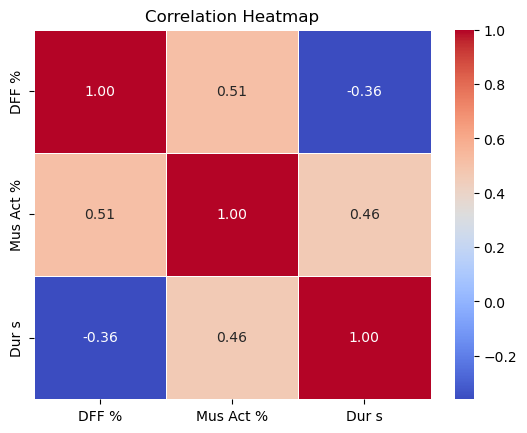

In [64]:
# Keep only REM and Wake
filtered_df = combined_df.query('State in ["R"]')

# Calculate correlations separately for each state
for state, data in filtered_df.groupby('State'):
    
    matrix = data[
        ['DFF %', 'Mus Act %', 'Dur s']
    ].corr()
    
    print(state)
    print(matrix)
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("Correlation Heatmap")
    plt.show()

After data cleaning, even advanced analyses like PCA, clustering, and machine learning often require just a single line of code. Cleaning and normalization are the most time-consuming steps, and also the most important, because they determine whether the results reflect real biology or artifacts of how the data was collected.